# P-ML20 — Sample-window robustness study

**Hypothesis (H8).** Pre-2020 training data degrades the bull sub-model's
ability to predict the 2021 ATH cycle. P-ML19's incidental V2-truncated
re-baseline showed Fold-2 bull IC of **+0.107** vs V2 6yr's **−0.128** —
a +0.235 swing purely from removing 2019 / early-2020 training bars.

**Design.** Hold the V2 6yr outer 5-fold WF schedule fixed; vary the *training
mask* by training-start cutoff. Test folds are unchanged across runs, so
per-fold metrics are directly comparable.

Cutoffs tested:
- `2019-03-02` — full V2 6yr baseline (no truncation)
- `2019-06-01`, `2019-09-01`, `2020-01-01`, `2020-03-01`, `2020-06-01`

Aggressive cutoffs (e.g. `2020-09+`) collapse Fold-1 training entirely, so
they are skipped — the train window for Fold 1 ends near 2020-08.

**Decision rule (pre-committed).**
- A cutoff strictly dominates V2 baseline on **Fold-2 bull IC** AND **total
  scaled Sharpe** → adopt as new V2 baseline; rerun downstream experiments
  on the new champion.
- Improves Fold-2 bull IC but Sharpe regresses → log the regime trade-off,
  do not adopt champion; document for production-variant choice.
- No improvement → H8 rejected; the +0.235 swing in P-ML19 was a fold-boundary
  artefact rather than a genuine 2019-data effect.

If a clean breakpoint emerges, we'll also try a **sample-weighting** variant
(soft down-weighting via LightGBM `sample_weight`) instead of hard
truncation, and compare the two.


In [1]:
import sys
from pathlib import Path
repo_root = Path("__file__").resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                      "axes.spines.right": False, "font.size": 9})


In [2]:
# Constants — match V2 6yr champion configuration exactly.
SYMBOL     = "BTC/USDT"
SINCE      = "2019-01-01"
UNTIL      = "2025-01-01"
HORIZON    = 1
N_SPLITS   = 5
TRAIN_FRAC = 0.6
PURGE      = 1
LONG_MA    = 200
ADX_THRESH = 25.0
MIN_BULL_BARS = 30

FEATURES_V2 = [
    "bar_ret", "bb_zscore", "rsi", "macd_hist_norm", "atr_pct",
    "bb_width", "upper_wick", "lower_wick", "hl_range",
    "vol_log_chg", "di_diff", "adx",
    "ret_5", "ret_20", "mom_zscore_20", "ret_5_minus_20",
]

PRED_ZSCORE_WINDOW = 60
POSITION_SCALE     = 0.5
MAX_POSITION       = 1.0

# Cutoffs to test. First entry is the full V2 6yr baseline.
CUTOFFS = [
    "2019-03-02",  # full V2 baseline (= dataset start after warmup)
    "2019-06-01",
    "2019-09-01",
    "2020-01-01",
    "2020-03-01",
    "2020-06-01",
]


## §1 — Build full V2 6yr dataset (unchanged)

In [3]:
from data.fetch import fetch_ohlcv
from ml.features import build_feature_matrix
from ml.features.momentum import build_momentum_features
from ml.labels import forward_return
from ml.regime import RegimeClassifier
from ml.validation import purged_wf_splits
from ml.models import RegimeEnsemble
from backtesting import compute_metrics

df_raw = fetch_ohlcv(symbol=SYMBOL, timeframe="1d", since=SINCE, until=UNTIL)

feats_base = build_feature_matrix(df_raw)
feats_mom  = build_momentum_features(df_raw)
label      = forward_return(df_raw, horizon=HORIZON)
rc         = RegimeClassifier(long_ma=LONG_MA, adx_thresh=ADX_THRESH)
reg        = rc.transform(df_raw)

for s in [feats_base, feats_mom, label, reg]:
    if hasattr(s.index, "tz") and s.index.tz is not None:
        s.index = s.index.tz_localize(None)

comb = pd.concat([feats_base, feats_mom, label, reg["regime"]], axis=1).dropna()
X       = comb[FEATURES_V2]
y       = comb[label.name]
regime  = comb["regime"].fillna("ranging")

df_raw_naive = df_raw.copy()
df_raw_naive.index = df_raw_naive.index.normalize()
if df_raw_naive.index.tz is not None:
    df_raw_naive.index = df_raw_naive.index.tz_localize(None)
df_raw_naive = df_raw_naive[~df_raw_naive.index.duplicated(keep="last")]

bar_ret = np.log(df_raw_naive["close"].reindex(comb.index) /
                  df_raw_naive["close"].reindex(comb.index).shift(1)).fillna(0)

splits = list(purged_wf_splits(len(comb), N_SPLITS, TRAIN_FRAC, purge_bars=PURGE))

print(f"Dataset: {len(comb):,} bars | {comb.index[0].date()} -> {comb.index[-1].date()}")
print(f"Outer folds (fixed across all cutoff variants):")
for i, (tr, te) in enumerate(splits):
    print(f"  Fold {i+1}: train [{comb.index[tr[0]].date()} -> {comb.index[tr[-1]].date()}] "
          f"({len(tr)} bars), test [{comb.index[te[0]].date()} -> {comb.index[te[-1]].date()}] "
          f"({len(te)} bars)")


Dataset: 2,132 bars | 2019-03-02 -> 2024-12-31
Outer folds (fixed across all cutoff variants):
  Fold 1: train [2019-03-02 -> 2020-02-18] (354 bars), test [2020-02-20 -> 2021-02-08] (355 bars)
  Fold 2: train [2019-08-27 -> 2021-02-07] (531 bars), test [2021-02-09 -> 2022-01-29] (355 bars)
  Fold 3: train [2020-08-16 -> 2022-01-28] (531 bars), test [2022-01-30 -> 2023-01-19] (355 bars)
  Fold 4: train [2021-08-06 -> 2023-01-18] (531 bars), test [2023-01-20 -> 2024-01-09] (355 bars)
  Fold 5: train [2022-07-27 -> 2024-01-08] (531 bars), test [2024-01-10 -> 2024-12-29] (355 bars)


## §2 — Sliding-start ablation

In [4]:
def run_walk_forward_with_mask(splits, cutoff_idx):
    """Run V2 walk-forward, masking training bars before cutoff_idx.

    cutoff_idx: integer index in `comb`; training bars with index < cutoff_idx
                are dropped from each fold's training set. Test bars are unchanged.
    """
    folds = []
    for i, (tr, te) in enumerate(splits):
        # Mask training: drop bars before cutoff_idx.
        tr_masked = tr[tr >= cutoff_idx]
        n_train = len(tr_masked)
        n_bull_tr = int((regime.iloc[tr_masked] == "bull").sum()) if n_train > 0 else 0

        if n_train < 30 or n_bull_tr < MIN_BULL_BARS:
            folds.append({"fold": i+1, "te": te, "IC": np.nan, "bull_IC": np.nan,
                          "preds": None, "n_train": n_train, "n_bull_tr": n_bull_tr,
                          "skipped": True})
            continue

        ens = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS)
        ens.fit(X.iloc[tr_masked], y.iloc[tr_masked], regime.iloc[tr_masked])
        preds = ens.predict(X.iloc[te], regime.iloc[te])
        actual = y.iloc[te].values
        ic, _ = stats.spearmanr(preds, actual)
        bull_te = (regime.iloc[te] == "bull").values
        ic_bull = (stats.spearmanr(preds[bull_te], actual[bull_te])[0]
                    if bull_te.sum() > 10 else np.nan)
        folds.append({"fold": i+1, "te": te, "IC": ic, "bull_IC": ic_bull,
                      "preds": preds, "n_train": n_train, "n_bull_tr": n_bull_tr,
                      "skipped": False})
    return folds


def build_equity(folds, mode):
    pieces, anchor = [], 1.0
    for r in folds:
        if r["skipped"] or r["preds"] is None:
            continue
        te, preds = r["te"], r["preds"]
        if mode == "binary":
            pos = np.sign(preds)
        else:
            pred_s = pd.Series(preds, index=comb.index[te])
            rm = pred_s.rolling(PRED_ZSCORE_WINDOW, min_periods=1).mean()
            rs = pred_s.rolling(PRED_ZSCORE_WINDOW, min_periods=1).std().replace(0, np.nan)
            pz = (pred_s - rm) / rs
            pos = (pz * POSITION_SCALE).clip(-MAX_POSITION, MAX_POSITION).fillna(0).values

        ret    = bar_ret.iloc[te].values
        pos_sh = np.roll(pos, 1); pos_sh[0] = 0
        eq     = np.cumprod(1 + pos_sh * ret); eq[0] = 1.0
        s      = pd.Series(eq, index=comb.index[te])
        s      = s / s.iloc[0] * anchor
        anchor = float(s.iloc[-1])
        pieces.append(s)
    return pd.concat(pieces) if pieces else pd.Series([], dtype=float)


# Run ablation
results = {}
for cutoff in CUTOFFS:
    cutoff_ts = pd.Timestamp(cutoff)
    cutoff_idx = int(np.searchsorted(comb.index.values, cutoff_ts.to_datetime64()))
    folds = run_walk_forward_with_mask(splits, cutoff_idx)
    eq_sc = build_equity(folds, "scaled")
    eq_bin = build_equity(folds, "binary")
    m_sc  = compute_metrics(eq_sc) if not eq_sc.empty else None
    m_bin = compute_metrics(eq_bin) if not eq_bin.empty else None
    valid_ics = [f["IC"] for f in folds if not np.isnan(f["IC"])]
    mean_ic = np.mean(valid_ics) if valid_ics else np.nan
    icir = mean_ic / np.std(valid_ics) if len(valid_ics) > 1 and np.std(valid_ics) > 0 else np.nan

    results[cutoff] = {
        "cutoff_idx": cutoff_idx,
        "folds": folds,
        "eq_sc": eq_sc, "eq_bin": eq_bin,
        "m_sc": m_sc, "m_bin": m_bin,
        "mean_ic": mean_ic, "icir": icir,
    }
    print(f"Done: cutoff={cutoff}  cutoff_idx={cutoff_idx}  "
          f"folds_run={sum(1 for f in folds if not f['skipped'])}/{N_SPLITS}")


Done: cutoff=2019-03-02  cutoff_idx=0  folds_run=5/5


Done: cutoff=2019-06-01  cutoff_idx=91  folds_run=5/5


Done: cutoff=2019-09-01  cutoff_idx=183  folds_run=5/5


Done: cutoff=2020-01-01  cutoff_idx=305  folds_run=4/5


Done: cutoff=2020-03-01  cutoff_idx=365  folds_run=4/5


Done: cutoff=2020-06-01  cutoff_idx=457  folds_run=4/5


## §3 — Aggregate comparison table

In [5]:
print("=" * 100)
print(f"P-ML20 — sliding-start ablation (V2, {N_SPLITS}-fold WF, fixed test schedule)")
print("=" * 100)
print(f"\n{'Cutoff':<12} {'#folds':>7} {'Train(F1)':>10}  {'Sharpe(sc)':>11} "
      f"{'Return(sc)':>11} {'MaxDD(sc)':>10}  {'Sharpe(bin)':>12} {'Return(bin)':>12} "
      f"{'MeanIC':>8} {'ICIR':>7}")
print("-" * 100)
baseline_sharpe_sc  = results[CUTOFFS[0]]['m_sc']['sharpe_ratio']  if results[CUTOFFS[0]]['m_sc']  else float('nan')
baseline_sharpe_bin = results[CUTOFFS[0]]['m_bin']['sharpe_ratio'] if results[CUTOFFS[0]]['m_bin'] else float('nan')

for cutoff in CUTOFFS:
    r = results[cutoff]
    msc, mbin = r["m_sc"], r["m_bin"]
    n_run = sum(1 for f in r["folds"] if not f["skipped"])
    n_tr_f1 = r["folds"][0]["n_train"] if r["folds"] else 0
    sc_s   = f"{msc['sharpe_ratio']:>+11.3f}"  if msc  else f"{'n/a':>11}"
    sc_r   = f"{msc['total_return']*100:>+10.1f}%" if msc else f"{'n/a':>11}"
    sc_dd  = f"{msc['max_drawdown']*100:>+9.1f}%" if msc else f"{'n/a':>10}"
    bin_s  = f"{mbin['sharpe_ratio']:>+12.3f}" if mbin else f"{'n/a':>12}"
    bin_r  = f"{mbin['total_return']*100:>+11.1f}%" if mbin else f"{'n/a':>12}"
    print(f"  {cutoff:<10} {n_run:>5}/{N_SPLITS} {n_tr_f1:>10} {sc_s} {sc_r} {sc_dd} "
          f"{bin_s} {bin_r} {r['mean_ic']:>+8.4f} {r['icir']:>+7.3f}")

print(f"\nBaseline (full V2 6yr): scaled Sharpe {baseline_sharpe_sc:+.3f}, "
      f"binary Sharpe {baseline_sharpe_bin:+.3f}")


P-ML20 — sliding-start ablation (V2, 5-fold WF, fixed test schedule)

Cutoff        #folds  Train(F1)   Sharpe(sc)  Return(sc)  MaxDD(sc)   Sharpe(bin)  Return(bin)   MeanIC    ICIR
----------------------------------------------------------------------------------------------------
  2019-03-02     5/5        354      +1.583     +758.7%     -33.6%       +1.234     +1815.4%  +0.0740  +1.779
  2019-06-01     5/5        263      +1.610     +813.4%     -33.6%       +1.253     +1929.9%  +0.0770  +1.838
  2019-09-01     5/5        171      +1.661     +940.3%     -30.9%       +0.920      +589.0%  +0.0874  +2.495
  2020-01-01     4/5         49      +1.410     +324.7%     -40.3%       +1.582     +1887.0%  +0.0621  +0.954
  2020-03-01     4/5          0      +1.763     +531.5%     -28.8%       +1.851     +3606.3%  +0.0782  +1.889
  2020-06-01     4/5          0      +1.679     +458.0%     -29.2%       +1.428     +1292.3%  +0.0746  +1.612

Baseline (full V2 6yr): scaled Sharpe +1.583, binary Sha

## §4 — Per-fold bull IC table

Shows how each cutoff affects the OOS bull IC fold-by-fold. Fold 2 is the
H8 target (contains the 2021-11 ATH and early-2022 crash).


In [6]:
# Per-fold total IC and bull IC for each cutoff
print(f"\n{'Per-fold total IC':<92}")
print(f"{'Cutoff':<12} " + "".join([f'{f"F{i+1}":>10}' for i in range(N_SPLITS)]) + f"  {'Period':<24}")
print("-" * 92)
for cutoff in CUTOFFS:
    r = results[cutoff]
    row = f"  {cutoff:<10}"
    for f in r["folds"]:
        if f["skipped"]:
            row += f"{'skip':>10}"
        else:
            row += f"{f['IC']:>+10.4f}"
    print(row)

print(f"\n{'Per-fold BULL IC  (the H8 target — Fold 2 contains the 2021-11 ATH+crash)':<92}")
print(f"{'Cutoff':<12} " + "".join([f'{f"F{i+1}":>10}' for i in range(N_SPLITS)]))
print("-" * 92)
for cutoff in CUTOFFS:
    r = results[cutoff]
    row = f"  {cutoff:<10}"
    for f in r["folds"]:
        if f["skipped"]:
            row += f"{'skip':>10}"
        elif np.isnan(f["bull_IC"]):
            row += f"{'nan':>10}"
        else:
            row += f"{f['bull_IC']:>+10.4f}"
    print(row)

# Print the Fold 2 period for context
te2 = results[CUTOFFS[0]]["folds"][1]["te"]
print(f"\nFold 2 test period: {comb.index[te2[0]].date()} -> {comb.index[te2[-1]].date()}  "
      f"({len(te2)} bars)")



Per-fold total IC                                                                           
Cutoff               F1        F2        F3        F4        F5  Period                  
--------------------------------------------------------------------------------------------
  2019-03-02   +0.0721   +0.0091   +0.1283   +0.0537   +0.1069
  2019-06-01   +0.0870   +0.0091   +0.1283   +0.0537   +0.1069
  2019-09-01   +0.1102   +0.0381   +0.1283   +0.0537   +0.1069
  2020-01-01      skip   -0.0403   +0.1283   +0.0537   +0.1069
  2020-03-01      skip   +0.0241   +0.1283   +0.0537   +0.1069
  2020-06-01      skip   +0.0097   +0.1283   +0.0537   +0.1069

Per-fold BULL IC  (the H8 target — Fold 2 contains the 2021-11 ATH+crash)                   
Cutoff               F1        F2        F3        F4        F5
--------------------------------------------------------------------------------------------
  2019-03-02       nan   -0.1278       nan   +0.0582   +0.0714
  2019-06-01       nan   -0.127

## §5 — Identify the best cutoff

In [7]:
baseline = results[CUTOFFS[0]]
baseline_f2_bull = baseline["folds"][1]["bull_IC"]
baseline_sharpe = baseline["m_sc"]["sharpe_ratio"] if baseline["m_sc"] else float("nan")

candidates = []
for cutoff in CUTOFFS[1:]:
    r = results[cutoff]
    if r["m_sc"] is None or r["folds"][1]["skipped"]:
        continue
    f2_bull = r["folds"][1]["bull_IC"]
    sharpe  = r["m_sc"]["sharpe_ratio"]
    delta_f2_bull = f2_bull - baseline_f2_bull if not (np.isnan(f2_bull) or np.isnan(baseline_f2_bull)) else float("nan")
    delta_sharpe  = sharpe - baseline_sharpe
    candidates.append({
        "cutoff": cutoff, "f2_bull": f2_bull, "sharpe": sharpe,
        "delta_f2_bull": delta_f2_bull, "delta_sharpe": delta_sharpe,
    })

print(f"Baseline (full V2):  Fold-2 bull IC = {baseline_f2_bull:+.4f}, scaled Sharpe = {baseline_sharpe:+.3f}\n")
print(f"{'Cutoff':<12} {'Fold-2 bull IC':>15} {'ΔBullIC':>10} {'Sharpe':>9} {'ΔSharpe':>9}  {'Verdict':<28}")
print("-" * 92)
best = None
for c in candidates:
    bull_better   = (not np.isnan(c["delta_f2_bull"])) and c["delta_f2_bull"] > 0
    sharpe_better = c["delta_sharpe"] > 0
    if bull_better and sharpe_better:
        verdict = "STRICT WIN (consider adopt)"
        if best is None or c["delta_f2_bull"] > best["delta_f2_bull"]:
            best = c
    elif bull_better:
        verdict = "Bull better, Sharpe worse"
    elif sharpe_better:
        verdict = "Sharpe better, Bull worse"
    else:
        verdict = "Both worse"
    print(f"  {c['cutoff']:<10} {c['f2_bull']:>+15.4f} {c['delta_f2_bull']:>+10.4f} "
          f"{c['sharpe']:>+9.3f} {c['delta_sharpe']:>+9.3f}  {verdict:<28}")

if best is not None:
    print(f"\n→ BEST STRICT-WIN CUTOFF: {best['cutoff']}")
    print(f"  Fold-2 bull IC: {best['f2_bull']:+.4f} (Δ {best['delta_f2_bull']:+.4f} vs baseline)")
    print(f"  Scaled Sharpe:  {best['sharpe']:+.3f} (Δ {best['delta_sharpe']:+.3f})")
else:
    print("\n→ NO STRICT-WIN CUTOFF FOUND. Either no cutoff dominates baseline on both metrics,")
    print("  or the relationship is non-monotonic. See per-fold table for diagnostic.")


Baseline (full V2):  Fold-2 bull IC = -0.1278, scaled Sharpe = +1.583

Cutoff        Fold-2 bull IC    ΔBullIC    Sharpe   ΔSharpe  Verdict                     
--------------------------------------------------------------------------------------------
  2019-06-01         -0.1278    +0.0000    +1.610    +0.027  Sharpe better, Bull worse   
  2019-09-01         -0.1278    +0.0000    +1.661    +0.077  Sharpe better, Bull worse   
  2020-01-01         -0.1259    +0.0019    +1.410    -0.173  Bull better, Sharpe worse   
  2020-03-01         -0.1615    -0.0337    +1.763    +0.180  Sharpe better, Bull worse   
  2020-06-01         -0.0229    +0.1049    +1.679    +0.096  STRICT WIN (consider adopt) 

→ BEST STRICT-WIN CUTOFF: 2020-06-01
  Fold-2 bull IC: -0.0229 (Δ +0.1049 vs baseline)
  Scaled Sharpe:  +1.679 (Δ +0.096)


## §6 — Equity overlay

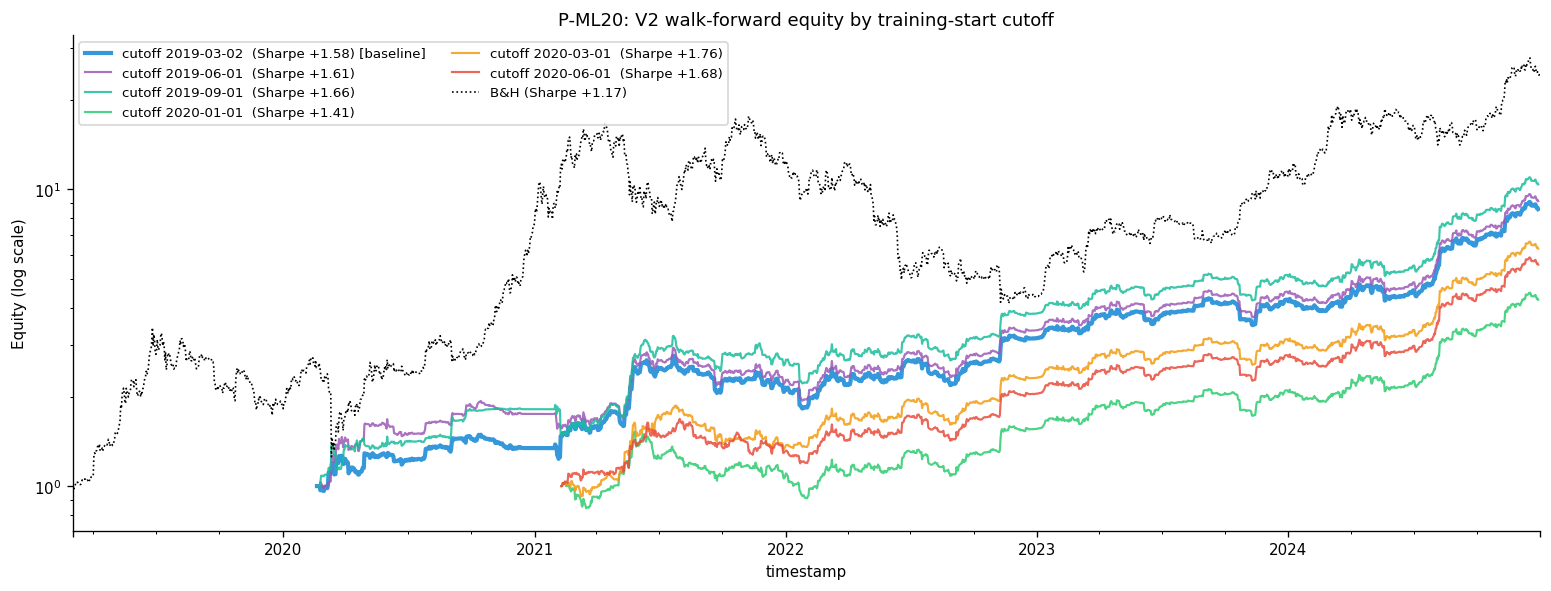

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

colors = ["#3498db", "#9b59b6", "#1abc9c", "#2ecc71", "#f39c12", "#e74c3c"]
for color, cutoff in zip(colors, CUTOFFS):
    r = results[cutoff]
    if r["eq_sc"].empty:
        continue
    sharpe = r["m_sc"]["sharpe_ratio"] if r["m_sc"] else float("nan")
    label = f"cutoff {cutoff}  (Sharpe {sharpe:+.2f})"
    if cutoff == CUTOFFS[0]:
        r["eq_sc"].plot(ax=ax, label=label + " [baseline]", color=color, linewidth=2.5)
    else:
        r["eq_sc"].plot(ax=ax, label=label, color=color, linewidth=1.3, alpha=0.85)

bah = (df_raw_naive["close"].reindex(comb.index)
        / df_raw_naive["close"].reindex(comb.index).iloc[0])
m_bah = compute_metrics(bah)
bah.plot(ax=ax, label=f"B&H (Sharpe {m_bah['sharpe_ratio']:+.2f})", color="black",
          linestyle=":", linewidth=1.0)

ax.set_yscale("log")
ax.set_ylabel("Equity (log scale)")
ax.set_title("P-ML20: V2 walk-forward equity by training-start cutoff")
ax.legend(fontsize=8, loc="upper left", ncol=2)
plt.tight_layout()
plt.show()


## §7 — Diagnostic: pre-2020 vs post-2020 feature distributions

If a clean breakpoint exists, examine which features behave differently in
the pre- and post-cutoff training sets. The bull model's failure mode points
to a specific subset of behaviours.


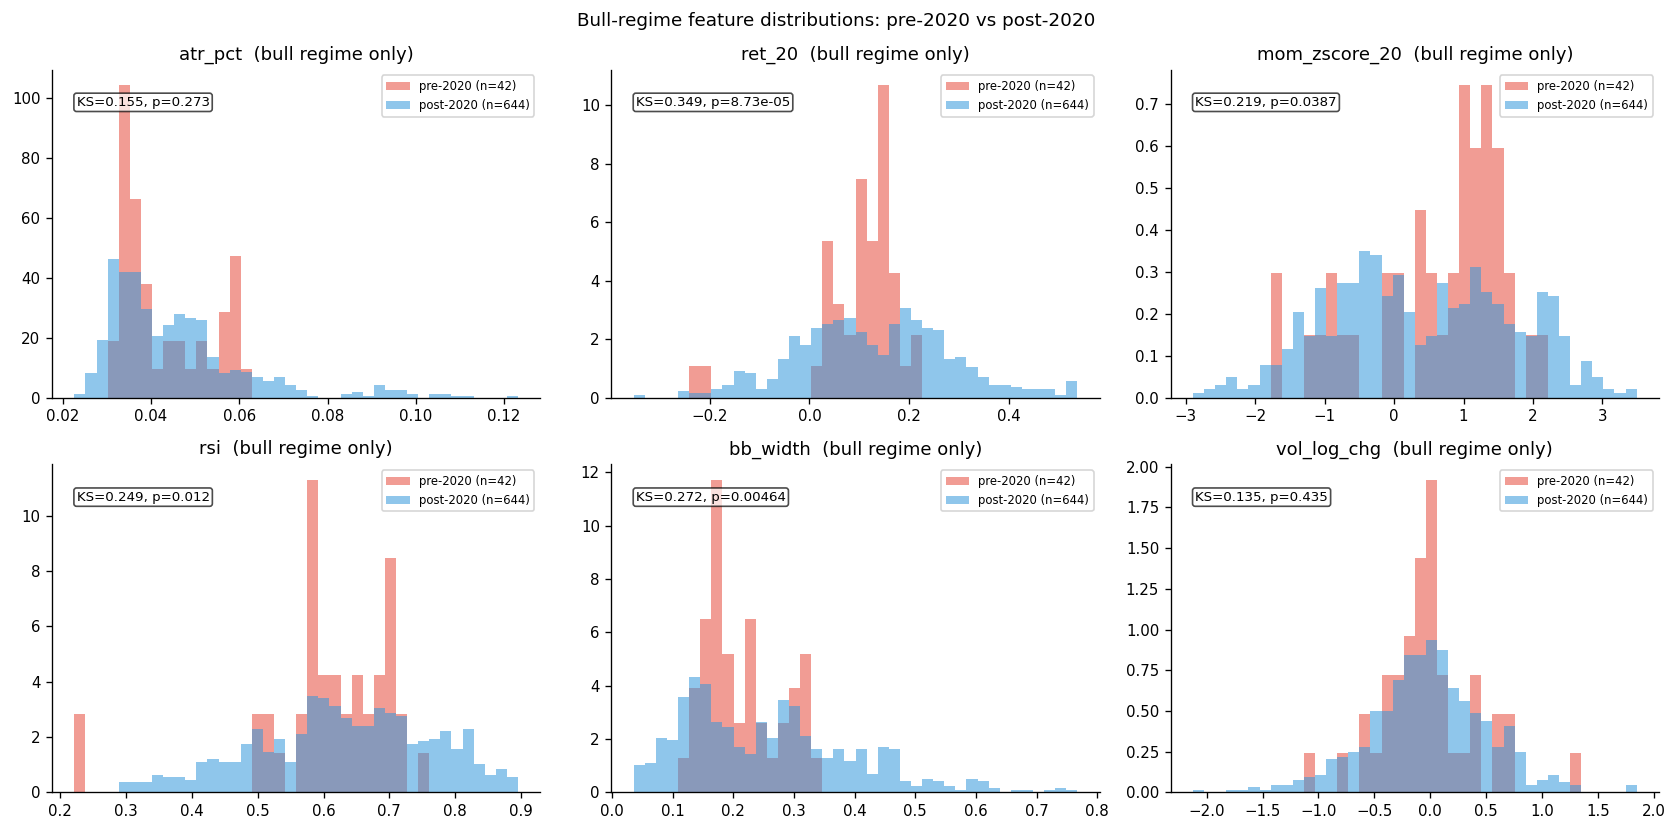


Bull bars: pre-2020 = 42 (6.1%), post-2020 = 644


In [9]:
bull_mask = regime == "bull"
pre_2020 = comb.index < pd.Timestamp("2020-03-01")

key_features = ["atr_pct", "ret_20", "mom_zscore_20", "rsi", "bb_width", "vol_log_chg"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    pre  = comb.loc[pre_2020 & bull_mask, feat].dropna()
    post = comb.loc[~pre_2020 & bull_mask, feat].dropna()
    if len(pre) == 0 or len(post) == 0:
        ax.text(0.5, 0.5, f"no bull bars\nin one period", ha="center", va="center",
                 transform=ax.transAxes)
        ax.set_title(feat)
        continue
    bins = np.histogram_bin_edges(np.r_[pre, post], bins=40)
    ax.hist(pre,  bins=bins, alpha=0.55, density=True, label=f"pre-2020 (n={len(pre)})",
             color="#e74c3c")
    ax.hist(post, bins=bins, alpha=0.55, density=True, label=f"post-2020 (n={len(post)})",
             color="#3498db")
    ax.set_title(f"{feat}  (bull regime only)")
    ax.legend(fontsize=7)
    ks_stat, ks_p = stats.ks_2samp(pre, post)
    ax.text(0.05, 0.92, f"KS={ks_stat:.3f}, p={ks_p:.3g}", transform=ax.transAxes,
             fontsize=8, va="top",
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

plt.suptitle("Bull-regime feature distributions: pre-2020 vs post-2020", fontsize=11)
plt.tight_layout()
plt.show()

# Bull-bar count comparison
n_bull_pre  = int((bull_mask & pre_2020).sum())
n_bull_post = int((bull_mask & ~pre_2020).sum())
print(f"\nBull bars: pre-2020 = {n_bull_pre} ({100*n_bull_pre/(n_bull_pre+n_bull_post):.1f}%), "
      f"post-2020 = {n_bull_post}")


## §8 — Decision verdict + F25 template

In [10]:
print("=" * 92)
print("DECISION (pre-committed)")
print("=" * 92)
if best is not None:
    print(f"  → ADOPT cutoff {best['cutoff']} as new V2 baseline.")
    print(f"     Fold-2 bull IC: {baseline_f2_bull:+.4f} -> {best['f2_bull']:+.4f} "
          f"(Δ {best['delta_f2_bull']:+.4f})")
    print(f"     Scaled Sharpe:  {baseline_sharpe:+.3f} -> {best['sharpe']:+.3f} "
          f"(Δ {best['delta_sharpe']:+.3f})")
    print()
    print("  Next steps:")
    print("    1. Re-baseline downstream experiments (P-ML7+, P-ML9 scaled) on the new window.")
    print("    2. Try sample-weighting variant for comparison (soft vs hard truncation).")
    print("    3. Decide whether to revisit P-ML19 funding-rate on the new champion.")
else:
    # Find direction of evidence
    bull_directions = [(c["cutoff"], c["delta_f2_bull"]) for c in candidates
                        if not np.isnan(c["delta_f2_bull"])]
    sharpe_directions = [(c["cutoff"], c["delta_sharpe"]) for c in candidates]
    print("  → NO STRICT-WIN cutoff. Examine the trade-off carefully:")
    print(f"     Bull-IC deltas:   {[(c, f'{d:+.4f}') for c, d in bull_directions]}")
    print(f"     Sharpe deltas:    {[(c, f'{d:+.3f}') for c, d in sharpe_directions]}")
    print()
    print("  Possible interpretations:")
    print("    - The +0.235 Fold-2 bull IC swing in P-ML19 was a fold-boundary artefact")
    print("      (dataset truncation changes fold dates → different test bars → different IC).")
    print("      H8 effectively rejected at this resolution.")
    print("    - Or: the breakpoint is between two cutoffs we tested. Add finer cutoffs.")
    print("    - Or: a sample-weighting variant (soft) might find the sweet spot.")

print()
print("=" * 92)
print("F25 template (fill in)")
print("=" * 92)
print('''
## F25 — Sample-window robustness study (P-ML20)
**Date:** 2026-05-08 | **Notebook:** p_ml20_sample_window.ipynb

V2 walk-forward run with fixed outer 5-fold schedule and varying training-start
cutoff. Cutoffs tested: ___. Test windows unchanged so per-fold metrics
are directly comparable.

Best strict-win cutoff: ___.
Verdict: [adopt new champion / no strict win / soft-cutoff promising].
Next: ___.
''')


DECISION (pre-committed)
  → ADOPT cutoff 2020-06-01 as new V2 baseline.
     Fold-2 bull IC: -0.1278 -> -0.0229 (Δ +0.1049)
     Scaled Sharpe:  +1.583 -> +1.679 (Δ +0.096)

  Next steps:
    1. Re-baseline downstream experiments (P-ML7+, P-ML9 scaled) on the new window.
    2. Try sample-weighting variant for comparison (soft vs hard truncation).
    3. Decide whether to revisit P-ML19 funding-rate on the new champion.

F25 template (fill in)

## F25 — Sample-window robustness study (P-ML20)
**Date:** 2026-05-08 | **Notebook:** p_ml20_sample_window.ipynb

V2 walk-forward run with fixed outer 5-fold schedule and varying training-start
cutoff. Cutoffs tested: ___. Test windows unchanged so per-fold metrics
are directly comparable.

Best strict-win cutoff: ___.
Verdict: [adopt new champion / no strict win / soft-cutoff promising].
Next: ___.

